In [1]:
# Import Pandas module
# Import NumPy module
import numpy as np
import pandas as pd
from sklearn import preprocessing

# We will cover data visualization in more details later in the semester.
# For now the only visualization that we'll explore is histograms.
# Histograms are helpful for visually examining distribution of a particular variable

# The following line is a directive that tells matplotlib module to display
# generated graphs inline with the output of your code
%matplotlib inline 

# Import matplotlib module.  Matplotlib module allows us to generate graphs from data
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

**Dealing With Different Data Scales**

Numeric variables are often on different scales and cover different ranges, so they can't be easily compared. What's more, variables with large values can dominate those with smaller values when using certain modeling techniques. Centering and scaling is a common preprocessing task that puts numeric variables on a common scale so no single variable will dominate the others.
The simplest way to center data is to subtract the mean value from each data point. Subtracting the mean centers the data around zero and sets the new mean to zero. 

The Scaling operations we introduced here are all linear operations, that is to say these operations will not change the shape (distribution) of the data. When looking at the histogram, the only change before and after scaling should only be the values of the x-axis.

**Z-score (Standard Score)**
Z-score is a common method for scaling. In most cases, you will be calcuating z-score on all the predictors/independent variables to make sure all are on a similar scales (usually between -3 and 3).

In [25]:
df = pd.read_csv("diabetes.csv")
df.dropna(inplace=True)
df.head()

,id,chol,stab.glu,hdl,ratio,glyhb,location,age,gender,height,weight,frame,bp.1s,bp.1d,waist,hip
0,1000,203.0,82,56.0,3.6,4.31,Buckingham,46,female,62.0,121.0,medium,118.0,59.0,29.0,38.0
1,1001,165.0,97,24.0,6.9,4.44,Buckingham,29,female,64.0,218.0,large,112.0,68.0,46.0,48.0
2,1002,228.0,92,37.0,6.2,4.64,Buckingham,58,female,61.0,256.0,large,190.0,92.0,49.0,57.0
3,1003,78.0,93,12.0,6.5,4.63,Buckingham,67,male,67.0,119.0,large,110.0,50.0,33.0,38.0
4,1005,249.0,90,28.0,8.9,7.72,Buckingham,64,male,68.0,183.0,medium,138.0,80.0,44.0,41.0


<Axes: >

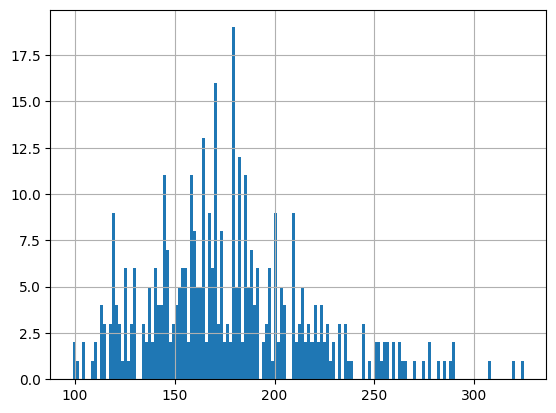

In [17]:
df['weight'].hist(bins=150)

<Axes: >

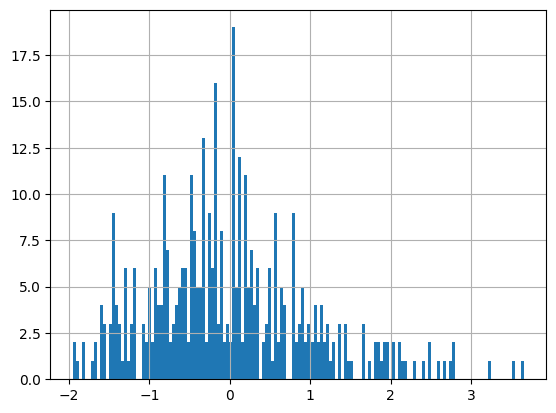

In [16]:
# Using Weight as an example
df["weight_zscore"] = (df['weight'] - df['weight'].mean()) / df['weight'].std()
df["weight_zscore"].hist(bins=150)

In [18]:
data_scale = preprocessing.scale(df[['chol', 'stab.glu', 'hdl', 'ratio', 'glyhb', 'age', 
                                 'height', 'weight', 'bp.1s', 'bp.1d', 'waist', 'hip']])  # Scale the data*
 
# Note: preprocessing.scale() returns ndarrays so we have to convert it back into a DataFrame.
df_scaled = pd.DataFrame(data_scale,    # Remake the DataFrame
                        columns=['chol', 'stab.glu', 'hdl', 'ratio', 'glyhb', 'age', 
                                 'height', 'weight', 'bp.1s', 'bp.1d', 'waist', 'hip'])

df_scaled.head()

,chol,stab.glu,hdl,ratio,glyhb,age,height,weight,bp.1s,bp.1d,waist,hip
0,-0.109163,-0.465424,0.322179,-0.534057,-0.571398,-0.052241,-1.027216,-1.404601,-0.832342,-1.792024,-1.555399,-0.892072
1,-0.965207,-0.182462,-1.533847,1.378171,-0.513354,-1.095693,-0.516176,1.002916,-1.096514,-1.128901,1.415505,0.877947
2,0.454024,-0.276783,-0.779837,0.972546,-0.424058,0.684313,-1.282736,1.946068,2.337726,0.639427,1.939782,2.470965
3,-2.925097,-0.257919,-2.229857,1.146385,-0.428522,1.236729,0.250384,-1.454241,-1.184572,-2.455147,-0.856363,-0.892072
4,0.927101,-0.314511,-1.301844,2.537097,0.951116,1.052590,0.505904,0.134224,0.048232,-0.244737,1.065987,-0.361066


**Min-Max Scaling**

Another option in scaling is to use Min-Max scaling.

In [21]:
min_max_scaler = preprocessing.MinMaxScaler(feature_range=(1,100)) # for this case, we will set the range between 1 and 100
scaled_data = min_max_scaler.fit_transform(df[['chol', 'stab.glu', 'hdl', 'ratio', 'glyhb', 'age', 
                                                'height', 'weight', 'bp.1s', 'bp.1d', 'waist', 'hip']])

df_scaled = pd.DataFrame(scaled_data,    # Remake the DataFrame
                        columns=['chol', 'stab.glu', 'hdl', 'ratio', 'glyhb', 'age', 
                                 'height', 'weight', 'bp.1s', 'bp.1d', 'waist', 'hip'])

df_scaled.describe()

,chol,stab.glu,hdl,ratio,glyhb,age,height,weight,bp.1s,bp.1d,waist,hip
count,402.000000,403.000000,402.000000,402.000000,390.000000,403.000000,398.000000,402.000000,398.000000,398.000000,401.000000,401.000000
mean,36.218442,18.236122,36.241501,17.805761,22.449526,38.770692,58.832915,35.427486,30.022173,47.011042,40.270823,38.969121
std,12.055096,15.592252,15.824074,9.610153,16.531413,22.122205,16.163874,17.671354,14.071014,17.701756,18.906732,16.471018
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,28.394521,10.694362,24.833333,10.455057,13.531645,21.342466,46.375000,23.778761,20.335938,36.171053,24.100000,27.205882
50%,35.175342,13.044510,32.166667,16.016854,16.922561,36.260274,58.750000,33.196903,29.462500,45.289474,37.300000,35.941176
75%,42.227397,18.038576,44.083333,22.691013,22.524942,56.602740,71.125000,45.243363,36.114063,55.710526,50.500000,47.588235
max,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000


In [22]:
# We can also reverse the sacling and transformation when using scikit-learn's preprocessing sub-module
original_data = min_max_scaler.inverse_transform(scaled_data)
df_original = pd.DataFrame(original_data,    # Remake the DataFrame
                        columns=['chol', 'stab.glu', 'hdl', 'ratio', 'glyhb', 'age', 
                                 'height', 'weight', 'bp.1s', 'bp.1d', 'waist', 'hip'])

df_original.head()

,chol,stab.glu,hdl,ratio,glyhb,age,height,weight,bp.1s,bp.1d,waist,hip
0,203.0,82.0,56.0,3.6,4.31,46.0,62.0,121.0,118.0,59.0,29.0,38.0
1,165.0,97.0,24.0,6.9,4.44,29.0,64.0,218.0,112.0,68.0,46.0,48.0
2,228.0,92.0,37.0,6.2,4.64,58.0,61.0,256.0,190.0,92.0,49.0,57.0
3,78.0,93.0,12.0,6.5,4.63,67.0,67.0,119.0,110.0,50.0,33.0,38.0
4,249.0,90.0,28.0,8.9,7.72,64.0,68.0,183.0,138.0,80.0,44.0,41.0


**Normalization**

In [26]:
X = df[['chol', 'stab.glu', 'hdl', 'ratio', 'glyhb', 'age', 
        'height', 'weight', 'bp.1s', 'bp.1d', 'waist', 'hip']]
normalizer = preprocessing.Normalizer().fit(X)

normalizer.transform(X)

array([[0.67149541, 0.27124445, 0.18524011, ..., 0.19516369, 0.09592792,
        0.12569865],
       [0.49452131, 0.29071859, 0.07193037, ..., 0.20380272, 0.13786655,
        0.14386074],
       [0.53050237, 0.21406236, 0.0860903 , ..., 0.21406236, 0.11401147,
        0.13262559],
       ...,
       [0.72299663, 0.22657289, 0.13747119, ..., 0.25457628, 0.08146441,
        0.1094678 ],
       [0.4745379 , 0.65799327, 0.09295072, ..., 0.17122501, 0.08072036,
        0.09784287],
       [0.58167345, 0.22214664, 0.15199507, ..., 0.22799261, 0.11984227,
        0.14030314]], shape=(367, 12))

**Dealing With Skewed Data**

The distribution of data - its overall shape and how it is spread out - can have a significant impact on analysis and modeling. Data that is roughly evenly spread around the mean value - known as normally distributed data - tends to be well-behaved. On the other hand, some data sets exhibit significant skewness or asymmetry. 

array([[<Axes: title={'center': '0'}>]], dtype=object)

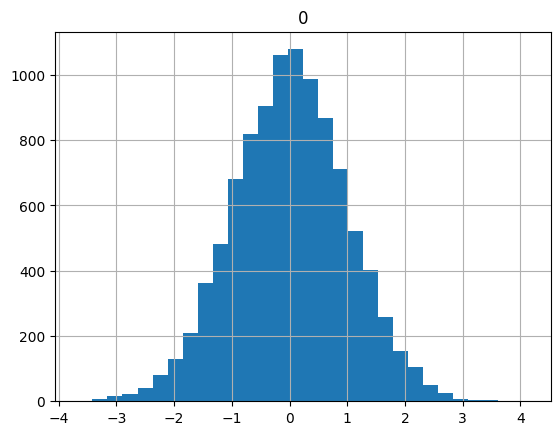

In [2]:
# Before we touch real data, let's generate a few sample distributions
normally_distributed = np.random.normal(size=10000)  # Generate normal data*

normally_distributed = pd.DataFrame(normally_distributed) # Convert to DF

normally_distributed.hist(bins=30)     # Plot histogram      

<Axes: ylabel='Density'>

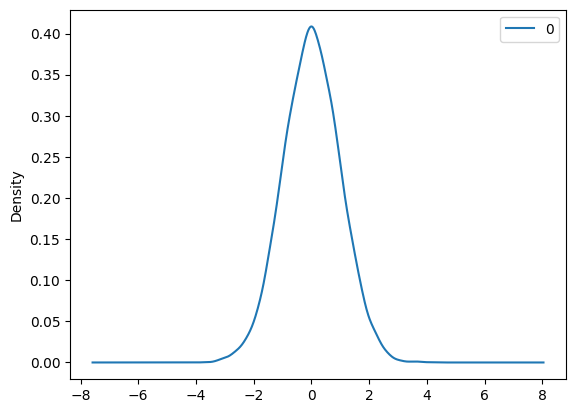

In [3]:
normally_distributed.plot.density()

array([[<Axes: title={'center': '0'}>]], dtype=object)

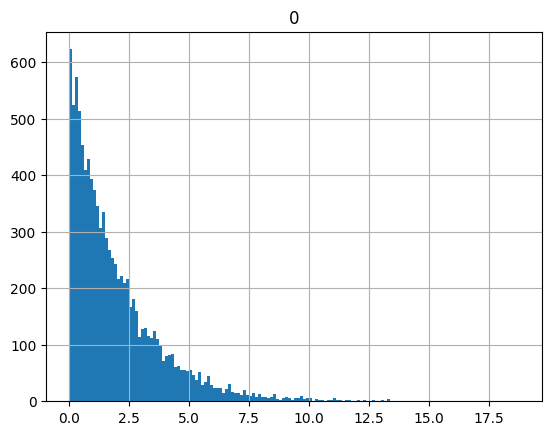

In [4]:
# Now let's generate some skewed data:
skewed = np.random.exponential(scale=2, size= 10000) # Generate skewed data
skewed = pd.DataFrame(skewed) # Convert to DF

skewed.hist(bins=150) # Plot histogram

<Axes: ylabel='Density'>

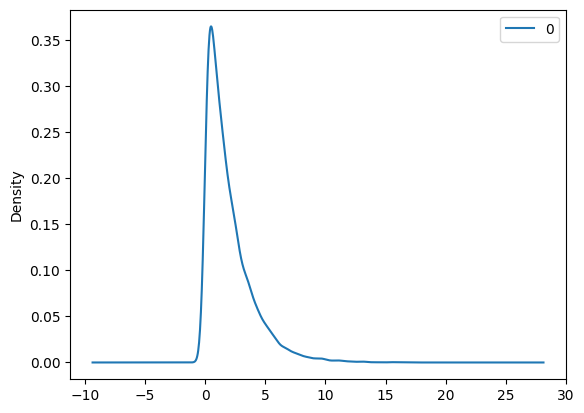

In [5]:
skewed.plot.density()

**Transforming Skewed Data**

Data with a long tail that goes off to the right is called positively skewed or right skewed. When you have a skewed distribution like the one above, the extreme values in the long tail can have a disproportionately large influence on whatever test you perform or models you build. Reducing skew may improve your results. Taking the square root of each data point or taking the natural logarithm of each data point are two simple transformations that can reduce skew.

array([[<Axes: title={'center': '0'}>]], dtype=object)

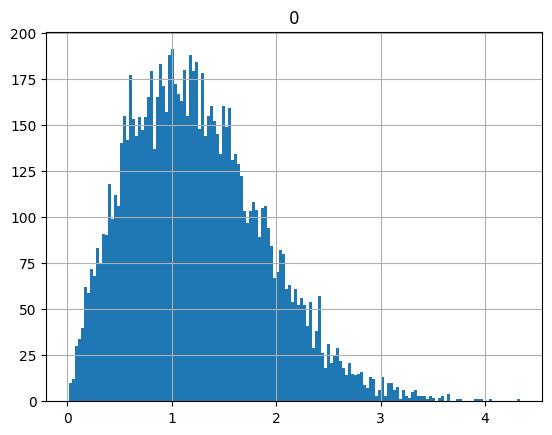

In [ ]:
# One option is to use square root 
sqrt_transformed = skewed.apply(np.sqrt) # Get the square root of data points*
sqrt_transformed.hist(bins=150) # Plot histogram

array([[<Axes: title={'center': '0'}>]], dtype=object)

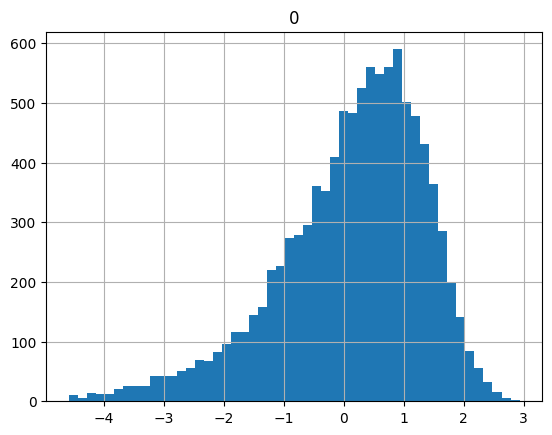

In [7]:
# Now let's try log transformation
log_transformed = (skewed+0.01).apply(np.log) # Get the log of the data
log_transformed.hist(bins=50) # Plot histogram

**Now let's try to do this with some real data**

In [ ]:
df.index = df.id       # Set row index to patient ID name
df_num = df[['chol', 'stab.glu', 'hdl', 'ratio', 'glyhb', 'age', 
             'height', 'weight', 'bp.1s', 'bp.1d', 'waist', 'hip']]
df_num.head()

,chol,stab.glu,hdl,ratio,glyhb,age,height,weight,bp.1s,bp.1d,waist,hip
id,,,,,,,,,,,,
1000,203.0,82,56.0,3.6,4.31,46,62.0,121.0,118.0,59.0,29.0,38.0
1001,165.0,97,24.0,6.9,4.44,29,64.0,218.0,112.0,68.0,46.0,48.0
1002,228.0,92,37.0,6.2,4.64,58,61.0,256.0,190.0,92.0,49.0,57.0
1003,78.0,93,12.0,6.5,4.63,67,67.0,119.0,110.0,50.0,33.0,38.0
1005,249.0,90,28.0,8.9,7.72,64,68.0,183.0,138.0,80.0,44.0,41.0


<Axes: >

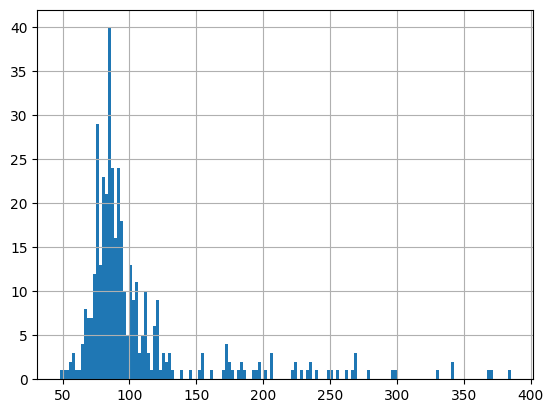

In [9]:
df_num["stab.glu"].hist(bins=150)

<Axes: >

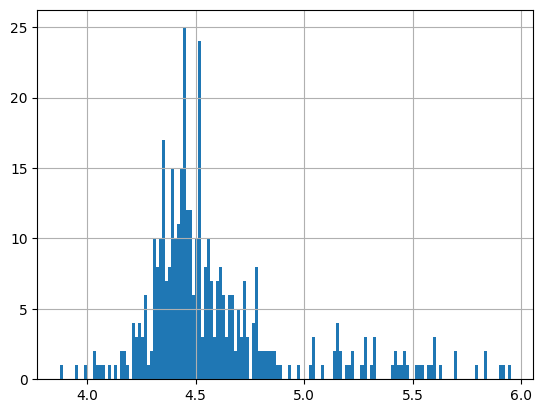

In [13]:
# Log transformation are a very popular option
log_transformed_col = (df_num["stab.glu"] + 0.1).apply(np.log) # Get the log of the data

log_transformed_col.hist(bins=150) # Plot histogram

# You can use scikit-learn's preprocessing module to do transformation as well.
# In this case, we will use the PowerTransformer

pt = preprocessing.PowerTransformer(method='yeo-johnson', standardize=False)
transformed = pd.DataFrame(pt.fit_transform(df_num[['stab.glu']]))
transformed.hist(bins=150)

**Highly Correlated Values**

In predictive modeling, each variable you use to construct a model would ideally represent some unique feature of the data. In other words, you want each variable to tell you something different. In reality, variables often exhibit collinearity - a strong correlation or tendency to move together, typically due to some underlying similarity or common influencing factor. Variables with strong correlations can interfere with one another when performing modeling and muddy results.
You can check the pairwise correlations between numeric variables using the df.corr() function:

**Understanding Correlations**

* A positive correlation implies that when one variable goes up the other tends to go up as well. 
* Negative correlations indicate an inverse relationship: when one variable goes up the other tends to go down. 
* A correlation near zero indicates low correlation 
* A correlation near -1 or 1 indicates a large negative or positive correlation.

In [33]:
# Check the pairwise correlations of all variables
df_num.corr()   

,chol,stab.glu,hdl,ratio,glyhb,age,height,weight,bp.1s,bp.1d,waist,hip
chol,1.000000,0.150092,0.186581,0.475521,0.247099,0.233119,-0.058858,0.066889,0.203344,0.171605,0.124489,0.079402
stab.glu,0.150092,1.000000,-0.161899,0.280349,0.749236,0.289258,0.090669,0.185453,0.166467,0.022014,0.218446,0.133502
hdl,0.186581,-0.161899,1.000000,-0.686907,-0.149145,0.038088,-0.101419,-0.290983,0.019804,0.065732,-0.268369,-0.210060
ratio,0.475521,0.280349,-0.686907,1.000000,0.328665,0.148510,0.094335,0.281649,0.119386,0.048193,0.304162,0.194622
glyhb,0.247099,0.749236,-0.149145,0.328665,1.000000,0.338929,0.063023,0.171882,0.197936,0.032375,0.226184,0.141401
age,0.233119,0.289258,0.038088,0.148510,0.338929,1.000000,-0.090493,-0.055970,0.443041,0.058227,0.149645,0.008819
height,-0.058858,0.090669,-0.101419,0.094335,0.063023,-0.090493,1.000000,0.251251,-0.047827,0.038598,0.051094,-0.107832
weight,0.066889,0.185453,-0.290983,0.281649,0.171882,-0.055970,0.251251,1.000000,0.090873,0.175956,0.849855,0.829115
bp.1s,0.203344,0.166467,0.019804,0.119386,0.197936,0.443041,-0.047827,0.090873,1.000000,0.596557,0.196489,0.136655
bp.1d,0.171605,0.022014,0.065732,0.048193,0.032375,0.058227,0.038598,0.175956,0.596557,1.000000,0.167110,0.145805


**Inspect the results!**

Inspecting the data table, we see that the weight and waste have fairly strong positive correlations to each other. This indicates that heavier patients have larger waist sizes.

An easy way to visualize result is using a heatmap.

In most scearios, any absolute correlation values that are larger than 0.5 should be a strong indication for the two variables being correlated. Best option here will be to remove one of them, or combine them into one single value.

<Axes: >

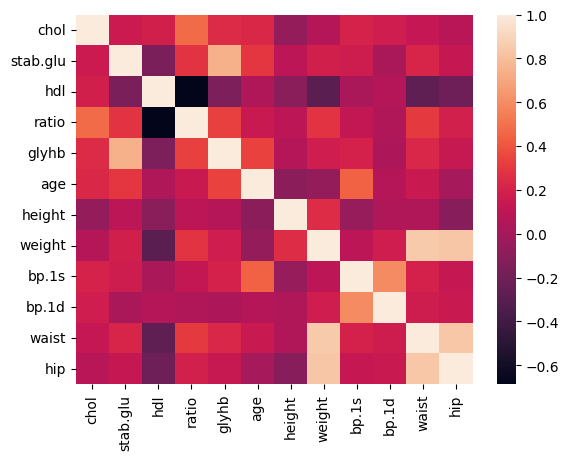

In [34]:
import seaborn as sns

sns.heatmap(df_num.corr())